In [3]:
import pandas as pd
import numpy as np
import tldextract
import math
import re
from collections import Counter

df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
raw_data = df[['URL', 'label']].copy()
print(raw_data['label'].value_counts())


label
1    134850
0    100945
Name: count, dtype: int64


In [2]:
!pip install tldextract pandas numpy

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [tldextract]
   -------------------- ------------------- 1/2 [tldextract]
   -------------------- ------------------- 1/2 [tldextract]
   ---------------------------------------- 2/2 [tldextract]



In [6]:
# --- Helper Function 1: Shannon Entropy (Measures Randomness) ---
# High entropy (e.g., 4.5) -> "cx923-1z.com" (Random/Phishing)
# Low entropy (e.g., 2.1) -> "google.com" (Structured/Safe)
def calculate_entropy(text):
    if not text:
        return 0
    counts = Counter(text)
    length = len(text)
    entropy = 0
    for count in counts.values():
        p = count / length
        entropy -= p * math.log2(p)
    return entropy

# --- Helper Function 2: Longest Character Continuation ---
# Measures the longest streak of a specific char type (like digits)
# Phishing sites often have long strings of numbers.
def longest_digit_continuation(text):
    longest = 0
    current = 0
    for char in text:
        if char.isdigit():
            current += 1
        else:
            longest = max(longest, current)
            current = 0
    return max(longest, current)

# --- The Main Extraction Function ---
def extract_features(url):
    # 1. Structural Extraction
    ext = tldextract.extract(url)
    domain_part = ext.domain + "." + ext.suffix
    subdomain_part = ext.subdomain
    
    features = {}

    # --- Feature Set 1: Lengths & Counts ---
    features['url_length'] = len(url)
    features['domain_length'] = len(domain_part)
    features['subdomain_count'] = len(subdomain_part.split('.')) if subdomain_part else 0
    
    # Count specific suspicious characters
    features['dot_count'] = url.count('.')
    features['at_count'] = url.count('@')
    features['hyphen_count'] = url.count('-')
    features['slash_count'] = url.count('/')
    
    # --- Feature Set 2: "Advanced" Mathematical Features ---
    # Shannon Entropy of the domain (very strong indicator)
    features['domain_entropy'] = calculate_entropy(domain_part)
    
    # Digit-to-Letter Ratio (DLR)
    # Phishing sites often use IP-like numbers or random digits
    total_chars = len(url)
    digit_count = sum(c.isdigit() for c in url)
    features['digit_ratio'] = digit_count / total_chars if total_chars > 0 else 0
    
    # Longest continuous string of numbers
    features['max_digit_streak'] = longest_digit_continuation(url)

    # --- Feature Set 3: Binary/Boolean Checks ---
    # Is IP Address? (e.g. http://192.168.0.1)
    # Regex checks for pattern digit.digit.digit.digit
    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features['is_ip'] = 1 if re.match(ip_pattern, ext.domain) else 0
    
    # Suspicious Keywords Check
    # (You can expand this list based on what you see in the dataset)
    suspicious_words = ['login', 'verify', 'update', 'secure', 'bank', 'account']
    features['has_sus_keyword'] = 1 if any(w in url.lower() for w in suspicious_words) else 0
    
    return features

# --- How to Run This on Your Dataset ---
def process_dataset(csv_path):
    print("Loading dataset...")
    df = pd.read_csv(csv_path)
    
    # IMPORTANT: Filter for only Label 0 (Phish) and Label 1 (Safe) if needed
    # df = df[df['label'].isin([0, 1])]

    print("Extracting features... this might take a minute...")
    # Apply the function to every URL row
    feature_data = df['URL'].apply(lambda x: pd.Series(extract_features(x)))
    
    # Combine features with the original label
    # REMEMBER: Your dataset uses 1=Safe, 0=Phish
    final_df = pd.concat([feature_data, df['label']], axis=1)
    
    return final_df


In [8]:
final_df = process_dataset('PhiUSIIL_Phishing_URL_Dataset.csv')
print(final_df.head())

Loading dataset...
Extracting features... this might take a minute...
   url_length  domain_length  subdomain_count  dot_count  at_count  \
0        32.0           20.0              1.0        2.0       0.0   
1        24.0           12.0              1.0        2.0       0.0   
2        30.0           18.0              1.0        3.0       0.0   
3        27.0           15.0              1.0        2.0       0.0   
4        34.0           22.0              1.0        2.0       0.0   

   hyphen_count  slash_count  domain_entropy  digit_ratio  max_digit_streak  \
0           0.0          2.0        3.546439          0.0               0.0   
1           1.0          2.0        3.251629          0.0               0.0   
2           0.0          2.0        3.572431          0.0               0.0   
3           0.0          2.0        3.506891          0.0               0.0   
4           0.0          2.0        3.413088          0.0               0.0   

   is_ip  has_sus_keyword  label  

Training on 188636 URLs...
Testing on 47159 URLs...
Training Complete!

Model Accuracy: 98.80%

--- Classification Report ---
                precision    recall  f1-score   support

  Phishing (0)       0.99      0.98      0.99     20189
Legitimate (1)       0.99      0.99      0.99     26970

      accuracy                           0.99     47159
     macro avg       0.99      0.99      0.99     47159
  weighted avg       0.99      0.99      0.99     47159



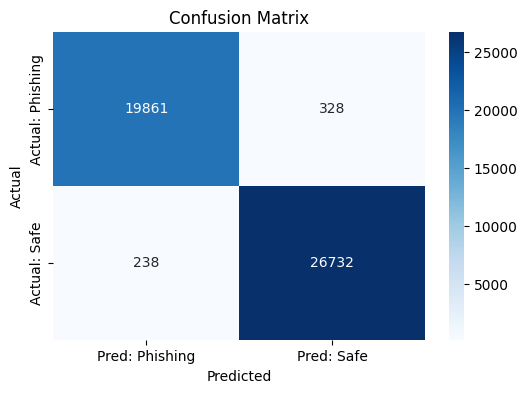


--- Top 5 Most Important Features ---
1. url_length (0.3045)
2. slash_count (0.2149)
3. domain_length (0.1469)
4. max_digit_streak (0.1054)
5. digit_ratio (0.0722)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = final_df.drop(['label'], axis=1) 
y = final_df['label']

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {X_train.shape[0]} URLs...")
print(f"Testing on {X_test.shape[0]} URLs...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Training Complete!")

y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc*100:.2f}%")


print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Phishing (0)', 'Legitimate (1)']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Phishing', 'Pred: Safe'],
            yticklabels=['Actual: Phishing', 'Actual: Safe'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

print("\n--- Top 5 Most Important Features ---")
for f in range(5):
    print(f"{f+1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

In [10]:
import joblib

joblib.dump(rf_model, 'phishing_model.pkl')
feature_order = list(X.columns)
joblib.dump(feature_order, 'feature_order.pkl')

print("Model and feature order saved successfully!")

Model and feature order saved successfully!


In [21]:
import requests

url = "http://127.0.0.1:5000/predict"
data = {
    "url": "https://www.google.com"
}

response = requests.post(url, json=data)
print(response.status_code)
print(response.json())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /predict (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x00000245BEA83B60>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))